In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

#cleaning the job_skills column by converting them from strings into lists
import ast
df['job_skills']=df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills )


In [3]:
#filtering out data analyst jobs in the US, removing NA salary values and exploding the skills column
df_us=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')]
df_us=df_us.dropna(subset='salary_year_avg')
df_exploded=df_us.explode('job_skills')

In [4]:
#grouping by skill count and median salary and sorting values based on skill count in descending order
df_new=df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_new=df_new.sort_values(by='count', ascending=False)

In [5]:
#Renaming the columns
df_new=df_new.rename(columns={'count':'skill_count', 'median':'median_salary'})

In [6]:
#calculating the length of the original dataframe to obtain the no. of job postings
job_count=len(df_us)

#creating a skill percent column in df_new 
df_new['skill_percent']= (df_new['skill_count']/job_count) * 100



In [8]:
#filtering out skill percentages above 5
skill_threshold=5
df_demand=df_new[df_new['skill_percent']> skill_threshold]

In [ ]:
#to color code the scatter plot, working on the job_type_skills column to convert it into a dataframe
df_tech=df['job_type_skills'].copy()

#removing duplicates
df_tech=df_tech.drop_duplicates()

#removing NAN values
df_tech=df_tech.dropna()

#combining all dictionaries into one
tech_dict={}
for row in df_tech:
    row_dict=ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in tech_dict:
            tech_dict[key] += value
        else:
            tech_dict[key] = value
for key, value in tech_dict.items():
    tech_dict[key]=list(set(value))

df_tech=pd.DataFrame(list(tech_dict.items()), columns=['technology','tools'])
df_tech=df_tech.explode('tools')

In [21]:
#merging df_tech and df_demand
df_plot=df_demand.merge(df_tech, left_on='job_skills', right_on='tools')

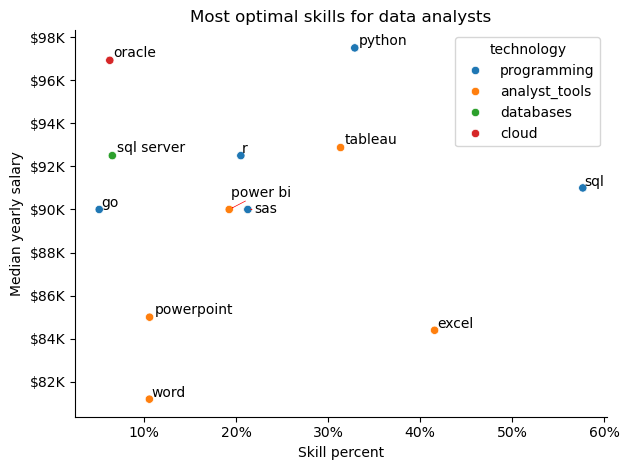

In [25]:
#plotting a scatter plot that displays the count and median salary associated with demanded skills
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter
sns.scatterplot(df_plot, x='skill_percent', y='median_salary', hue='technology')
plt.xlabel('Skill percent')
plt.ylabel('Median yearly salary')
plt.title('Most optimal skills for data analysts')
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=False))


#creating labels for the datapoints
skills=[]
for i, txt in enumerate(df_demand.index):
    skills.append(plt.text(df_demand['skill_percent'].iloc[i], df_demand['median_salary'].iloc[i], txt))

adjust_text(skills,arrowprops=dict(arrowstyle='->',color='red',lw=0.5))

sns.despine()
plt.tight_layout()
plt.show()